In [1]:
# Importation des module Python nécéssaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1 - Analyse global 

### 1-1 Comparaisons entre les deux élections 

In [2]:
#Européennes 

eur24 = pd.read_csv("res_europeennes_24.csv",sep=";",encoding="ISO-8859-1")

eur24 = eur24.rename(columns = {"ï»¿id_bv":"id_bv"})
eur24 = eur24.set_index('id_bv',drop='True')



#Legislative 


leg24 = pd.read_csv("res_legislatives_24.csv",sep=";",encoding="ISO-8859-1")

leg24 = leg24.rename(columns = {"ï»¿id_bv":"id_bv"})
leg24 = leg24.set_index('id_bv',drop='True')




In [3]:
eur24.columns

Index(['nb_procu', 'taux_procu', 'nb_inscr', 'nb_abscent', 'taux_abst',
       'nb_emarg', 'nb_votant', 'nb_bl', 'nb_nul', 'nb_exprim', 'NB_ExtGauche',
       'NB_Gauche', 'NB_Centre', 'NB_Droite', 'NB_ExtDroite', 'NB_Divers',
       'voix_Gauche', 'voix_Droite'],
      dtype='object')

In [4]:
#Chiffres des perticipations aux européennes 

part_eur = [np.sum(eur24["nb_abscent"]),np.sum(eur24["nb_bl"])+np.sum(eur24["nb_nul"]),np.sum(eur24["nb_exprim"])]

part_eur

[556185, 8167, 814577]

In [5]:
#Chiffres des participations aux législatives


part_leg = [541445,(np.sum(leg24["nb_bl"])+np.sum(leg24["nb_nul"])),np.sum(leg24["nb_exprim"])]

part_leg

[541445, 12543, 987423]

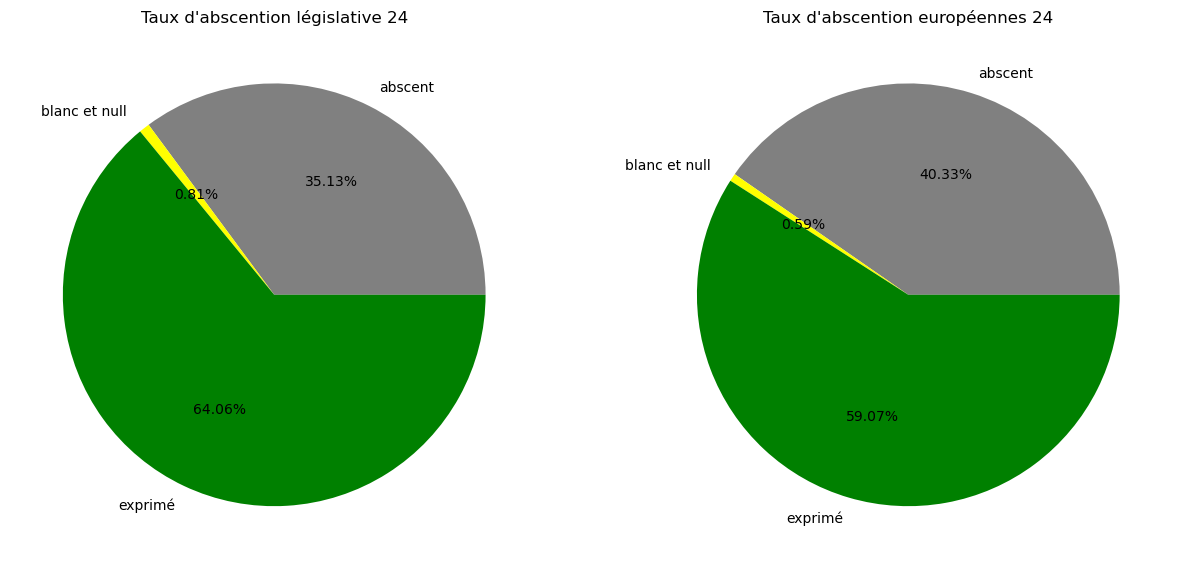

In [6]:
# distribution 


plt.figure(figsize=(15,12))

plt.subplot(1, 2, 1)
plt.pie(part_leg,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abscention législative 24")



plt.subplot(1, 2, 2)
plt.pie(part_eur,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abscention européennes 24")


plt.savefig("abs_global_2ELCT.png")

plt.show()




On a une baise de taux d'abstention entre les deux élections 

### 1-2 Distribution des deux abstention


On va travailler les distribution des taux d'abtentions avec l'aide de la boite à moustache 



In [7]:
eur24.columns

Index(['nb_procu', 'taux_procu', 'nb_inscr', 'nb_abscent', 'taux_abst',
       'nb_emarg', 'nb_votant', 'nb_bl', 'nb_nul', 'nb_exprim', 'NB_ExtGauche',
       'NB_Gauche', 'NB_Centre', 'NB_Droite', 'NB_ExtDroite', 'NB_Divers',
       'voix_Gauche', 'voix_Droite'],
      dtype='object')

In [8]:
leg24.columns

Index(['num_circo', 'nb_procu', 'nb_inscr', 'nb_emarg', 'nb_votant', 'nb_bl',
       'nb_nul', 'nb_exprim', 'NB_ExtGauche', 'NB_Gauche', 'NB_Centre',
       'NB_Droite', 'NB_ExtDroite', 'NB_Divers'],
      dtype='object')

In [9]:
#Distribution des abstentionniste par BV

eur24["taux_ab"] = (eur24["nb_inscr"]-eur24["nb_exprim"])/eur24["nb_inscr"]


abst_eur = pd.DataFrame(eur24["taux_ab"].describe())

abst_eur

,taux_ab
count,902.000000
mean,0.409103
std,0.066860
min,0.286357
25%,0.363629
50%,0.392890
75%,0.438646
max,0.793745


In [10]:
leg24["taux_ab"] = (leg24["nb_inscr"]-leg24["nb_votant"])/leg24["nb_inscr"]

abst_leg = pd.DataFrame(leg24["taux_ab"].describe())

abst_leg

,taux_ab
count,901.000000
mean,0.266799
std,0.051466
min,0.167608
25%,0.230273
50%,0.254226
75%,0.293734
max,0.472943


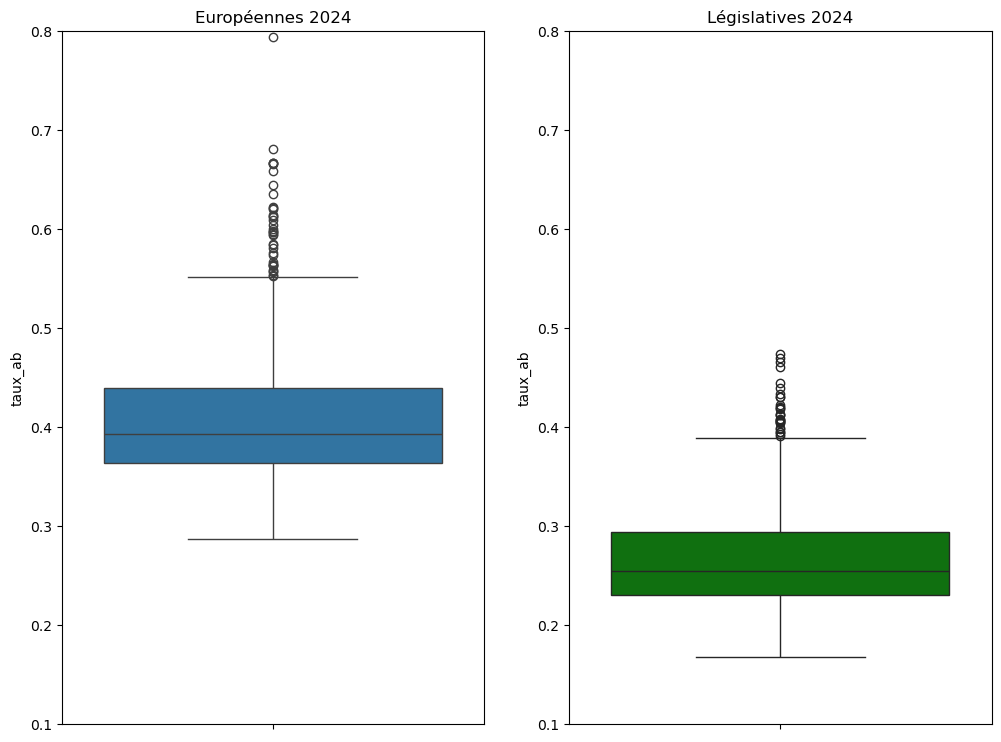

In [11]:
### Représentation grphique sous forme de boite à moustache 

# distribution 

plt.figure(figsize = (12,9))


plt.subplot(1, 2, 1)
sns.boxplot(eur24["taux_ab"])
plt.ylim(0.1,0.8)
plt.title("Européennes 2024")


plt.subplot(1, 2, 2)
sns.boxplot(leg24["taux_ab"],color="green")
plt.ylim(0.1,0.8)
plt.title("Législatives 2024")


plt.savefig("Boxplot_abst.png")


plt.show()

On a eu des écarts plus importants des taux d'abstention lors des élections européennes dans nos bureau de vote 

### 1-3 Ecarts des abstent 

On va voir la distribution des écarts d'abstention en nombre de voix 

In [12]:

#Legislative 2024

leg24["nb_abscent"] = leg24["nb_inscr"] - leg24["nb_votant"]

abst_leg24 = pd.DataFrame(leg24["nb_abscent"])
abst_leg24 = abst_leg24.rename(columns = {'nb_abscent':'abs_leg'})


# Européennes 2024

abst_eur24 = pd.DataFrame(eur24["nb_abscent"])
abst_eur24 = abst_eur24.rename(columns = {"nb_abscent":"abs_eur"})



#Fusion des deux tables 

abst = abst_eur24.merge(abst_leg24,on="id_bv")


abst["écart"] = abst["abs_leg"] - abst["abs_eur"]

abst

,abs_eur,abs_leg,écart
id_bv,,,
01_01,456,299,-157
01_02,537,307,-230
01_03,468,337,-131
01_04,569,383,-186
01_05,444,254,-190
...,...,...,...
20_72,785,516,-269
20_73,657,406,-251
20_74,634,413,-221


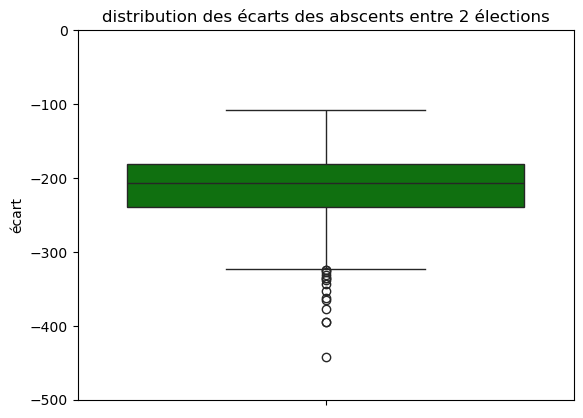

In [13]:
# distribution des écart d'abstention 

sns.boxplot(abst["écart"],color="green")
plt.ylim(-500,0)
plt.title("distribution des écarts des abscents entre 2 élections")

plt.savefig("écart_vote.png")

plt.show()

Les écarts entre les deux élections sont tous négatifs , donc on a une bonne augmentation de participation lors des élection législatives 

# 2 - Analyse par tendance politiques 

On va analyser les taux d'abstention par tendances poliques (gauche et droite)

### 2-1 Parties de gauches 

Le but est de voir les taux d'abstention pour les parties de gauches entre le Partie Socialiste et la France Insoumise 


In [14]:
#Ouverture des jeux de données des résultats des voix de gauche 

gauche = pd.read_csv("res_gauche.csv",sep=";",encoding="ISO-8859-1")

gauche = gauche.rename(columns = {"ï»¿id_bv":"id_bv"})

gauche = gauche.set_index('id_bv',drop="True")

gauche.head(10)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant
id_bv,,,,,,,,,,,,
01_01,295,282,-13,0.4617,0.3648,136,66,4,84,3,2,Partie Socialiste
01_02,329,312,-17,0.4796,0.3486,171,72,5,71,9,1,Partie Socialiste
01_03,369,323,-46,0.4933,0.3730,178,86,11,86,5,3,Partie Socialiste
01_04,390,434,44,0.5328,0.4822,175,66,15,125,5,4,Partie Socialiste
01_05,338,321,-17,0.5248,0.3924,173,79,5,75,5,1,Partie Socialiste
01_06,379,339,-40,0.4834,0.3742,189,88,8,87,3,4,Partie Socialiste
01_07,303,259,-44,0.4202,0.3213,156,60,8,70,4,5,Partie Socialiste
01_08,181,173,-8,0.3261,0.2574,96,47,3,34,1,0,Partie Socialiste
01_09,166,148,-18,0.2862,0.2229,91,28,2,43,2,0,Partie Socialiste


In [15]:
# Fusion des données 

gauche_abst = gauche.merge(abst,on='id_bv')

gauche_abst.head(5)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant,abs_eur,abs_leg,écart
id_bv,,,,,,,,,,,,,,,
01_01,295,282,-13,0.4617,0.3648,136,66,4,84,3,2,Partie Socialiste,456,299,-157
01_02,329,312,-17,0.4796,0.3486,171,72,5,71,9,1,Partie Socialiste,537,307,-230
01_03,369,323,-46,0.4933,0.3730,178,86,11,86,5,3,Partie Socialiste,468,337,-131
01_04,390,434,44,0.5328,0.4822,175,66,15,125,5,4,Partie Socialiste,569,383,-186
01_05,338,321,-17,0.5248,0.3924,173,79,5,75,5,1,Partie Socialiste,444,254,-190


On va se concentrer sur les deux éléctions 


#### Européennes 2024 

In [16]:
eur24_taux_ab = pd.DataFrame(eur24["taux_ab"])

eur24_taux_ab.head(5)

,taux_ab
id_bv,
01_01,0.418562
01_02,0.443182
01_03,0.389388
01_04,0.441221
01_05,0.409174


In [17]:
# Fusion des données 

gauche = gauche.merge(eur24_taux_ab,on="id_bv")

gauche = gauche.rename(columns = {"taux_ab":"taux_ab_eur"})

gauche.head(5)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant,taux_ab_eur
id_bv,,,,,,,,,,,,,
01_01,295,282,-13,0.4617,0.3648,136,66,4,84,3,2,Partie Socialiste,0.418562
01_02,329,312,-17,0.4796,0.3486,171,72,5,71,9,1,Partie Socialiste,0.443182
01_03,369,323,-46,0.4933,0.3730,178,86,11,86,5,3,Partie Socialiste,0.389388
01_04,390,434,44,0.5328,0.4822,175,66,15,125,5,4,Partie Socialiste,0.441221
01_05,338,321,-17,0.5248,0.3924,173,79,5,75,5,1,Partie Socialiste,0.409174


In [18]:
leg24["taux_ab_leg"] = pd.DataFrame((leg24["nb_inscr"]-leg24["nb_votant"])/leg24["nb_inscr"])

leg24_taux_ab = pd.DataFrame(leg24["taux_ab_leg"])

leg24_taux_ab.head(5)

,taux_ab_leg
id_bv,
01_01,0.276852
01_02,0.253509
01_03,0.278282
01_04,0.295753
01_05,0.235840


In [19]:
# Fusion des données 

gauche = gauche.merge(leg24_taux_ab,on="id_bv")

gauche.head(5)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant,taux_ab_eur,taux_ab_leg
id_bv,,,,,,,,,,,,,,
01_01,295,282,-13,0.4617,0.3648,136,66,4,84,3,2,Partie Socialiste,0.418562,0.276852
01_02,329,312,-17,0.4796,0.3486,171,72,5,71,9,1,Partie Socialiste,0.443182,0.253509
01_03,369,323,-46,0.4933,0.3730,178,86,11,86,5,3,Partie Socialiste,0.389388,0.278282
01_04,390,434,44,0.5328,0.4822,175,66,15,125,5,4,Partie Socialiste,0.441221,0.295753
01_05,338,321,-17,0.5248,0.3924,173,79,5,75,5,1,Partie Socialiste,0.409174,0.235840


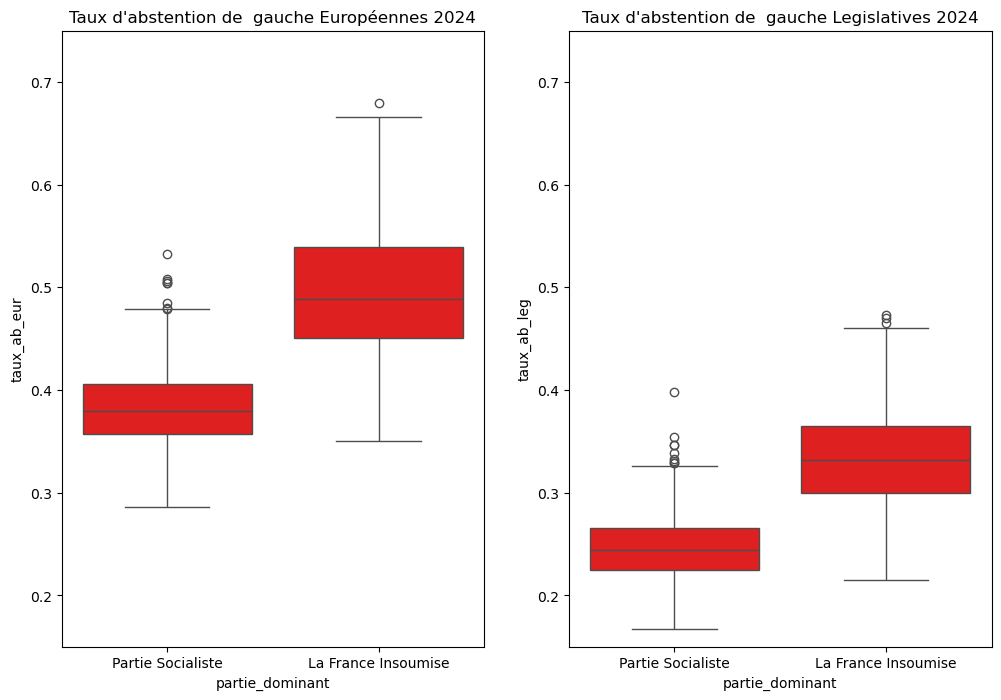

In [20]:
# Distributon par parties 

plt.figure(figsize =(12,8))


plt.subplot(1, 2, 1)
sns.boxplot(x = gauche["partie_dominant"],y=gauche["taux_ab_eur"],data=gauche,color="red")
plt.ylim(0.15,0.75)
plt.title("Taux d'abstention de  gauche Européennes 2024")


plt.subplot(1, 2, 2)
sns.boxplot(x = gauche["partie_dominant"],y=gauche["taux_ab_leg"],data=gauche,color="red")
plt.ylim(0.15,0.75)
plt.title("Taux d'abstention de  gauche Legislatives 2024")



plt.savefig("boxplot_taux_abs_gauche_partie.png")

plt.show()

### 2-2 Partie de Droite

Le but est de voir les taux d'abstention pour les parties de droites entre les Républicains et le Rassemblement Nationale 



In [21]:
#Ouverture des jeux de données des résultats des voix de gauche 

droite = pd.read_csv("res_droite.csv",sep=";",encoding="ISO-8859-1")

droite = droite.rename(columns = {"ï»¿id_bv":"id_bv"})
droite = droite.set_index('id_bv',drop="True")

#On ne prend pas le partie de "Reconquête"
droite = droite[droite["partie_dominant"].isin(["Les RÃ©publicains","Rassemblement National"])]

droite

,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite,partie_dominant
id_bv,,,,,,,,,,,
01_01,188,0.2942,166,0.2147,-22,72,60,42,2,12,Les RÃ©publicains
01_02,154,0.2245,164,0.1832,10,54,54,37,2,7,Les RÃ©publicains
01_03,183,0.2447,195,0.2252,12,58,71,37,0,17,Rassemblement National
01_04,175,0.2391,151,0.1678,-24,51,69,34,1,20,Rassemblement National
01_05,153,0.2376,138,0.1687,-15,44,53,41,3,12,Rassemblement National
...,...,...,...,...,...,...,...,...,...,...,...
20_72,133,0.1377,119,0.0984,-14,32,58,23,6,14,Rassemblement National
20_73,119,0.1096,104,0.0807,-15,30,46,21,1,21,Rassemblement National
20_74,106,0.0936,98,0.0742,-8,31,35,17,2,21,Rassemblement National


In [22]:
#Fusion avec les taux d'abstentéisme aux éléections 

droite = droite.merge(eur24_taux_ab,on="id_bv")
droite = droite.rename(columns = {"taux_ab":"taux_ab_eur"})


droite = droite.merge(leg24_taux_ab,on="id_bv")
droite = droite.rename(columns = {"taux_ab":"taux_ab_leg"})


droite.head(5)

,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite,partie_dominant,taux_ab_eur,taux_ab_leg
id_bv,,,,,,,,,,,,,
01_01,188,0.2942,166,0.2147,-22,72,60,42,2,12,Les RÃ©publicains,0.418562,0.276852
01_02,154,0.2245,164,0.1832,10,54,54,37,2,7,Les RÃ©publicains,0.443182,0.253509
01_03,183,0.2447,195,0.2252,12,58,71,37,0,17,Rassemblement National,0.389388,0.278282
01_04,175,0.2391,151,0.1678,-24,51,69,34,1,20,Rassemblement National,0.441221,0.295753
01_05,153,0.2376,138,0.1687,-15,44,53,41,3,12,Rassemblement National,0.409174,0.235840


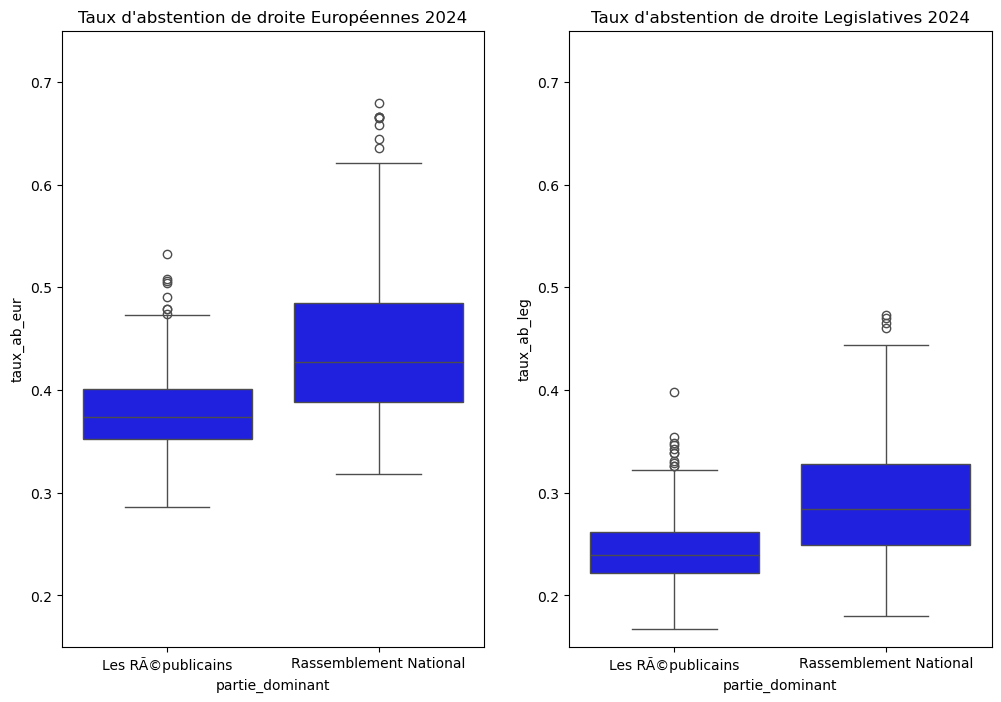

In [23]:
# Distributon par parties 

plt.figure(figsize =(12,8))


plt.subplot(1, 2, 1)
sns.boxplot(x = droite["partie_dominant"],y=droite["taux_ab_eur"],data=droite,color="blue")
plt.ylim(0.15,0.75)
plt.title("Taux d'abstention de droite Européennes 2024")


plt.subplot(1, 2, 2)
sns.boxplot(x = droite["partie_dominant"],y=droite["taux_ab_leg"],data=droite,color="blue")
plt.ylim(0.15,0.75)
plt.title("Taux d'abstention de droite Legislatives 2024")



plt.savefig("boxplot_taux_abs_droite_partie.png")

plt.show()

# 3 - Développement local 


### 3-1 Logement 

On va analyser les taux d'abstentéisme selon le type de logement 

In [24]:
#Ouverture du fichier des logement 

logement = pd.read_csv('logement.csv',sep=';',encoding='ISO-8859-1')


logement = logement.rename(columns = {'ID Bureau':'id_bv'})
logement = logement.set_index('id_bv',drop='True')


logement.head(5)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2
id_bv,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0
01_03,ancien_conforme,déficit,0.05,0.80,10.0
01_04,ancien_conforme,déficit,0.05,0.80,10.3
01_05,ancien_conforme,conforme,0.30,0.80,9.5


In [25]:
#On va fusionner les données des logement avec les données électorales (legislative)

logement_leg = logement.merge(leg24,on='id_bv')

logement_leg.head(5)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,...,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,taux_ab,nb_abscent,taux_ab_leg
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7,1,129,1080,781,781,...,773,3,279,324,70,96,1,0.276852,299,0.276852
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0,1,137,1211,904,904,...,895,0,312,414,73,91,5,0.253509,307,0.253509
01_03,ancien_conforme,déficit,0.05,0.80,10.0,1,140,1211,874,874,...,866,8,315,346,65,130,2,0.278282,337,0.278282
01_04,ancien_conforme,déficit,0.05,0.80,10.3,1,133,1295,912,912,...,900,18,416,315,45,106,0,0.295753,383,0.295753
01_05,ancien_conforme,conforme,0.30,0.80,9.5,1,145,1077,823,823,...,818,1,320,356,56,82,3,0.235840,254,0.235840


In [26]:
# On va découper les données en fonction des type de logement 

#ancien_standing
abs_standing = logement_leg[logement_leg['habitat_principal'] == "ancien_standing"]


#ancien_conforme
abs_conforme = logement_leg[logement_leg['habitat_principal'] == "ancien_conforme"]

#ancien_non_conforme
abs_non_conforme = logement_leg[logement_leg['habitat_principal'] == "ancien_non_conforme"]

#privé récent 
abs_prive = logement_leg[logement_leg['habitat_principal'] == "privé récent"]


#logement social
abs_social = logement_leg[logement_leg['habitat_principal'] == "logement_social"]


#individuel
abs_individuel = logement_leg[logement_leg['habitat_principal'] == "individuel"]


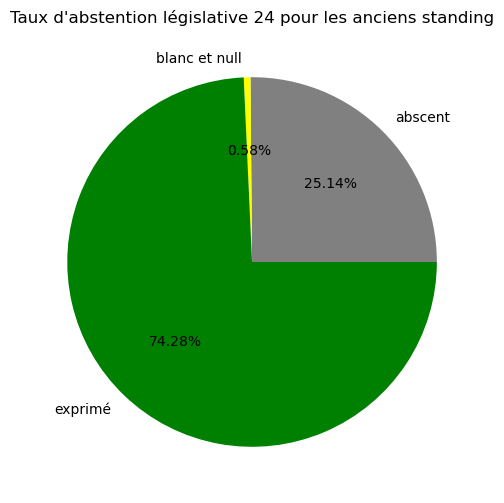

In [27]:
### Ancien standing



standing = [(np.sum(abs_standing['nb_inscr']-abs_standing['nb_votant'])),
            (np.sum(abs_standing["nb_bl"])+np.sum(abs_standing["nb_nul"])),
             np.sum(abs_standing["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(standing,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les anciens standing")

plt.savefig("abs_standing.png")

plt.show()

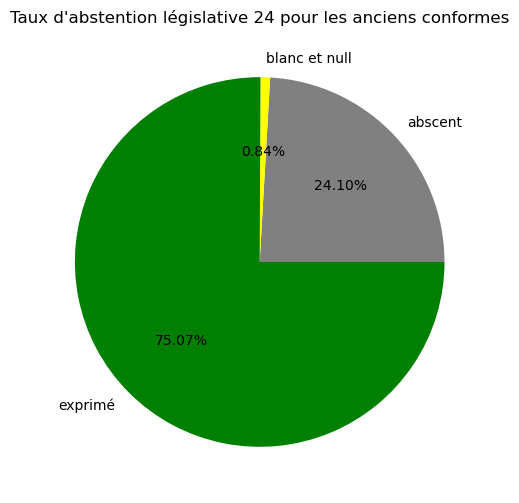

In [28]:
### Ancien conforme



conforme = [(np.sum(abs_conforme['nb_inscr']-abs_conforme['nb_votant'])),
            (np.sum(abs_conforme["nb_bl"])+np.sum(abs_conforme["nb_nul"])),
             np.sum(abs_conforme["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(conforme,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les anciens conformes")

plt.savefig("abs_conforme.png")

plt.show()

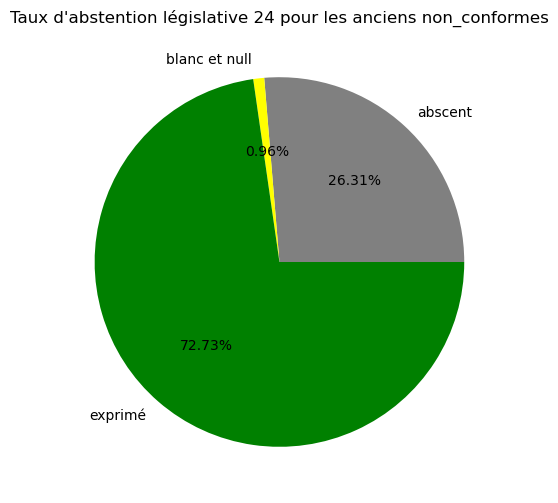

In [29]:
### Ancien non conforme



non_conforme = [(np.sum(abs_non_conforme['nb_inscr']-abs_non_conforme['nb_votant'])),
            (np.sum(abs_non_conforme["nb_bl"])+np.sum(abs_non_conforme["nb_nul"])),
             np.sum(abs_non_conforme["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(non_conforme,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les anciens non_conformes")

plt.savefig("abs_non_conforme.png")

plt.show()

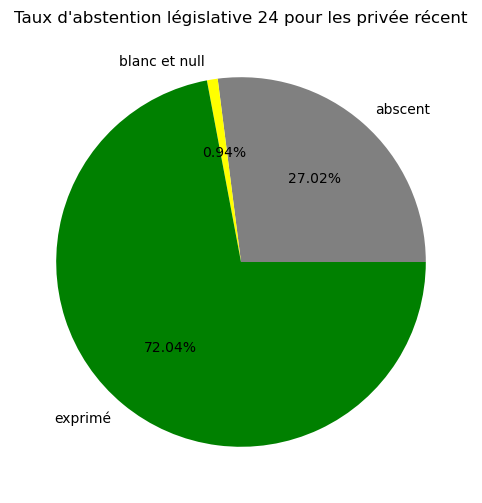

In [30]:
### Privé récent



prive = [(np.sum(abs_prive['nb_inscr']-abs_prive['nb_votant'])),
            (np.sum(abs_prive["nb_bl"])+np.sum(abs_prive["nb_nul"])),
             np.sum(abs_prive["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(prive,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les privée récent")

plt.savefig("abs_privé.png")

plt.show()

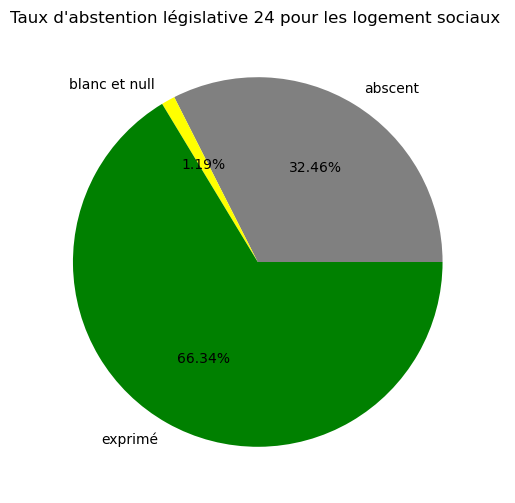

In [31]:
### Logement social

social = [(np.sum(abs_social['nb_inscr']-abs_social['nb_votant'])),
         (np.sum(abs_social["nb_bl"])+np.sum(abs_social["nb_nul"])),
          np.sum(abs_social["nb_exprim"])]


# diagramme circulaire 

plt.figure(figsize=(10,6))

plt.pie(social,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les logement sociaux ")

plt.savefig("abs_social.png")

plt.show()

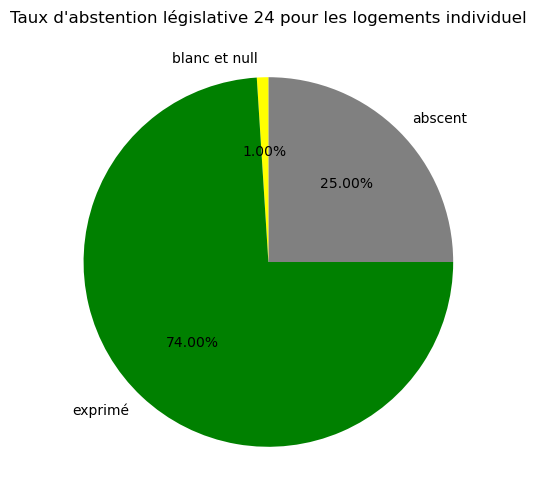

In [32]:
### Indoviduel



individuel = [(np.sum(abs_individuel['nb_inscr']-abs_individuel['nb_votant'])),
         (np.sum(abs_individuel["nb_bl"])+np.sum(abs_individuel["nb_nul"])),
          np.sum(abs_individuel["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(individuel,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","green"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les logements individuel")

plt.savefig("abs_individuel.png")

plt.show()

On constate que les résulats sont quasiment identiques mais on pourrait remarquer qu'on a plus d'avantage d'abstention dans les électeurs inscrit vivant dans les logment sociaux 

### 3-2 Commerce parisien 

On va analyser les abstention selon les types de commerce que peuvent y rencontrer les électeurs selon les bureau de vote 

In [33]:
#Ouverture des fichier de commerces perisiens 

commerce = pd.read_csv("commerce.csv",sep=";",encoding="ISO-8859-1")

commerce = commerce.rename(columns = {'ID Bureau': 'id_bv'})

commerce = commerce.set_index('id_bv',drop="True")
commerce.head(5)

,Type_centralités,type_commerce,densité
id_bv,,,
01_01,infra-métropolitaines,luxe,moyenne
01_02,infra-métropolitaines,proximités,forte
01_03,métropolitaine,ludiques,forte
01_04,métropolitaine,ludiques,forte
01_05,métropolitaine,diversifié,forte


In [34]:
#On va fusionner les données des commerce avec les données électorales (legislative)

commerce_leg = commerce.merge(leg24,on='id_bv')

commerce_leg.head(5)

,Type_centralités,type_commerce,densité,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,taux_ab,nb_abscent,taux_ab_leg
id_bv,,,,,,,,,,,,,,,,,,,,
01_01,infra-métropolitaines,luxe,moyenne,1,129,1080,781,781,7,1,773,3,279,324,70,96,1,0.276852,299,0.276852
01_02,infra-métropolitaines,proximités,forte,1,137,1211,904,904,5,4,895,0,312,414,73,91,5,0.253509,307,0.253509
01_03,métropolitaine,ludiques,forte,1,140,1211,874,874,3,5,866,8,315,346,65,130,2,0.278282,337,0.278282
01_04,métropolitaine,ludiques,forte,1,133,1295,912,912,7,5,900,18,416,315,45,106,0,0.295753,383,0.295753
01_05,métropolitaine,diversifié,forte,1,145,1077,823,823,3,2,818,1,320,356,56,82,3,0.235840,254,0.235840


In [35]:
commerce_leg["type_commerce"].value_counts()

type_commerce
peu commerciale    299
proximités         297
agglomération      185
diversifié          67
populaire           29
luxe                13
ludiques            10
antiquaire           1
Name: count, dtype: int64

In [36]:
#Divier les données part type de commerce 


#Ancien conforme
abs_agglomeration = commerce_leg[commerce_leg['type_commerce'] == 'agglomération']

#Ancien non conforme
abs_antique = commerce_leg[commerce_leg['type_commerce'] == 'antiquaire']

#Ancien standing
abs_diversite = commerce_leg[commerce_leg['type_commerce'] == 'diversifié']

#Résidence privé récent
abs_ludique = commerce_leg[commerce_leg['type_commerce'] == 'ludiques']

#Logement sociale 
abs_luxe = commerce_leg[commerce_leg['type_commerce'] == 'luxe']

#individuel 
abs_proximite = commerce_leg[commerce_leg['type_commerce'] == 'proximités']

#Logement sociale 
abs_populaire = commerce_leg[commerce_leg['type_commerce'] == 'populaire']

#individuel 
abs_peu_com = commerce_leg[commerce_leg['type_commerce'] == 'peu commerciale']

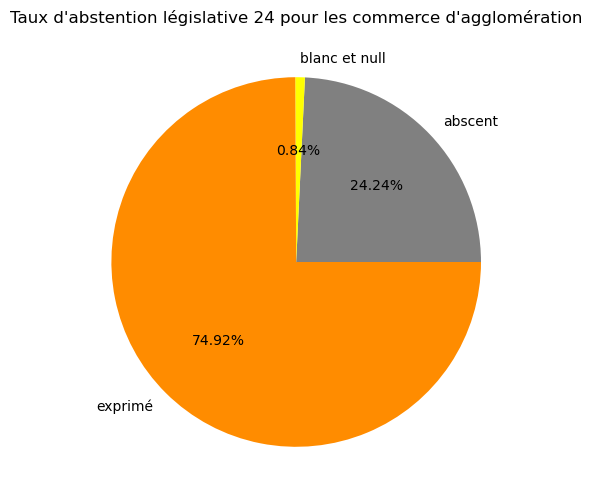

In [37]:
### agglomération



agglomeration = [(np.sum(abs_agglomeration['nb_inscr']-abs_agglomeration['nb_votant'])),
              (np.sum(abs_agglomeration["nb_bl"])+np.sum(abs_agglomeration["nb_nul"])),
               np.sum(abs_agglomeration["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(agglomeration,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce d'agglomération")

plt.savefig("abs_agglomeration.png")

plt.show()

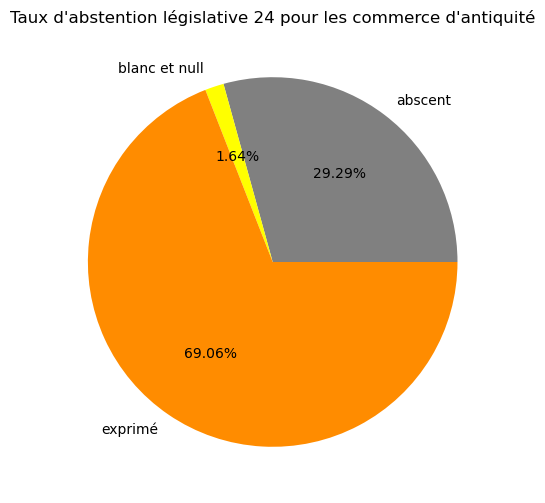

In [38]:
### antiquité



antique = [(np.sum(abs_antique['nb_inscr']-abs_antique['nb_votant'])),
           (np.sum(abs_antique["nb_bl"])+np.sum(abs_antique["nb_nul"])),
            np.sum(abs_antique["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(antique,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce d'antiquité")

plt.savefig("abs_antique.png")

plt.show()

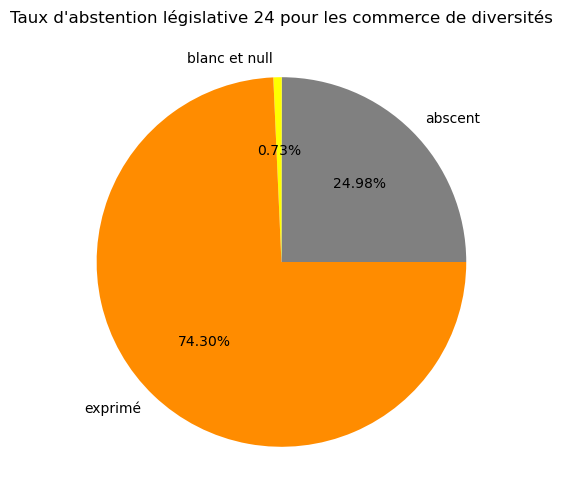

In [39]:
### diversité



diversite = [(np.sum(abs_diversite['nb_inscr']-abs_diversite['nb_votant'])),
           (np.sum(abs_diversite["nb_bl"])+np.sum(abs_diversite["nb_nul"])),
            np.sum(abs_diversite["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(diversite,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce de diversités")

plt.savefig("abs_diversite.png")

plt.show()

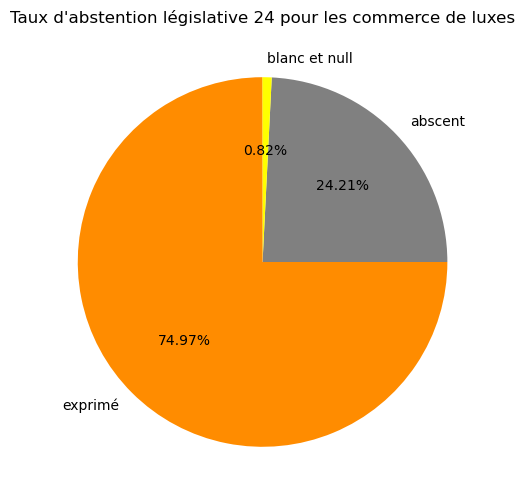

In [40]:
### de luxe



luxe = [(np.sum(abs_luxe['nb_inscr']-abs_luxe['nb_votant'])),
           (np.sum(abs_luxe["nb_bl"])+np.sum(abs_luxe["nb_nul"])),
            np.sum(abs_luxe["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(luxe,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce de luxes")

plt.savefig("abs_luxe.png")

plt.show()

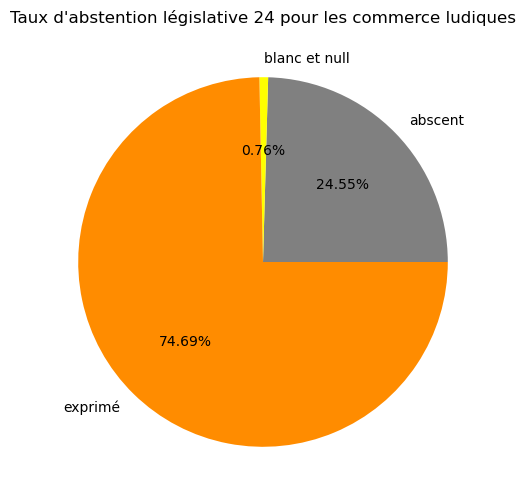

In [41]:
### de ludique

ludique = [(np.sum(abs_ludique['nb_inscr']-abs_ludique['nb_votant'])),
           (np.sum(abs_ludique["nb_bl"])+np.sum(abs_ludique["nb_nul"])),
            np.sum(abs_ludique["nb_exprim"])]


# distribution 

plt.figure(figsize=(10,6))

plt.pie(ludique,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce ludiques")

plt.savefig("abs_ludique.png")

plt.show()

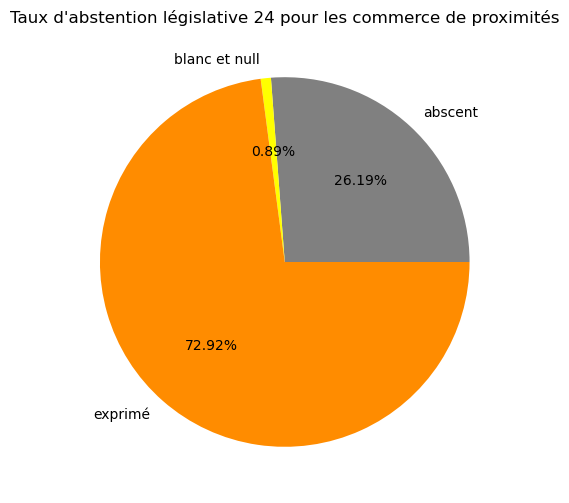

In [42]:
### de proximités



proximite = [(np.sum(abs_proximite['nb_inscr']-abs_proximite['nb_votant'])),
             (np.sum(abs_proximite["nb_bl"])+np.sum(abs_proximite["nb_nul"])),
              np.sum(abs_proximite["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(proximite,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce de proximités")

plt.savefig("abs_proximités.png")

plt.show()

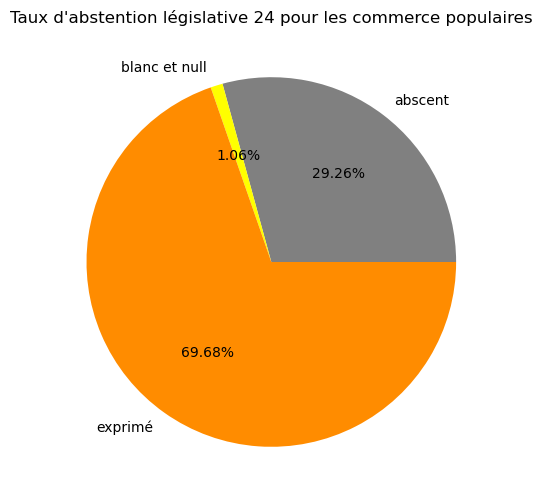

In [43]:
### de populairés



populaire = [(np.sum(abs_populaire['nb_inscr']-abs_populaire['nb_votant'])),
             (np.sum(abs_populaire["nb_bl"])+np.sum(abs_populaire["nb_nul"])),
              np.sum(abs_populaire["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(populaire,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 pour les commerce populaires")

plt.savefig("abs_populaires.png")

plt.show()

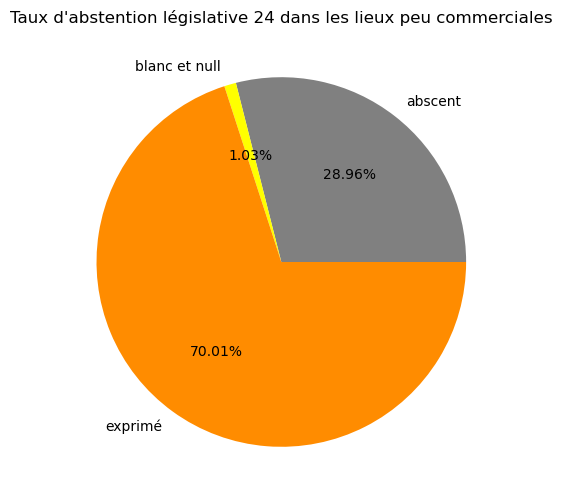

In [44]:
### de populairés



peu_com = [(np.sum(abs_peu_com['nb_inscr']-abs_peu_com['nb_votant'])),
             (np.sum(abs_peu_com["nb_bl"])+np.sum(abs_peu_com["nb_nul"])),
              np.sum(abs_peu_com["nb_exprim"])]


# distribution 


plt.figure(figsize=(10,6))

plt.pie(peu_com,labels = ["abscent","blanc et null ","exprimé"],colors = ["grey","yellow","darkorange"] ,autopct = '%.2f%%')
plt.title("Taux d'abstention législative 24 dans les lieux peu commerciales")

plt.savefig("abs_peu_commerciale.png")

plt.show()

Les proportions des abstentionniste sont assez équivalente mais on remarque qu'il y a une part plus important dans les lieux peu commerciales et des commerces populaires 

# 3 - Abstentionnisme en liaison avec d'autres variables  quantitatives 

In [45]:
leg24.head(5)

,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,taux_ab,nb_abscent,taux_ab_leg
id_bv,,,,,,,,,,,,,,,,,
01_01,1,129,1080,781,781,7,1,773,3,279,324,70,96,1,0.276852,299,0.276852
01_02,1,137,1211,904,904,5,4,895,0,312,414,73,91,5,0.253509,307,0.253509
01_03,1,140,1211,874,874,3,5,866,8,315,346,65,130,2,0.278282,337,0.278282
01_04,1,133,1295,912,912,7,5,900,18,416,315,45,106,0,0.295753,383,0.295753
01_05,1,145,1077,823,823,3,2,818,1,320,356,56,82,3,0.235840,254,0.235840


### Organisation des données 

Le but qu'on regroupe tous les variables nécessaires pour construire une matrice de corrélation 

In [46]:
###  Taux d'abstention
taux_abstention = pd.DataFrame(leg24["taux_ab"])


#Taux de procuration 
taux_procuration = pd.DataFrame(leg24["nb_procu"]/leg24["nb_inscr"])


#Jeux de données de population 

jeune = pd.read_csv("jeunes_0608.csv",sep=";",encoding="ISO-8859-1")
jeune = jeune.set_index("id_bv",drop=True) 




nb_jeune = pd.DataFrame(jeune["nombre_jeune"])


#Jeux de données de population 

population = pd.read_csv("population.csv",sep=";",encoding="ISO-8859-1")
population = population.set_index("id_bv",drop=True)                           


#age moyen 
age_moyen = pd.DataFrame(population["age_moyen"])

#revenu annuel
revenu_annuel = pd.DataFrame(population["revenu_annuel"])



### Jeux de données des logements

logement = pd.read_csv("logement.csv",sep=";",encoding="ISO-8859-1")
logement = logement.rename(columns = {"ID Bureau":"id_bv"})
logement = logement.set_index("id_bv",drop=True)                           


#prix immobilié
prix_immo = pd.DataFrame(logement["prix_immo_m2"])
#Taux de logement à 1 ou 2 pièces
p_T1_T2 = pd.DataFrame(logement["pourct_T1/T2"])
#Taux de logement sociaux
p_social = pd.DataFrame(logement["pour_logSocial"])



# Jeux de données des étranger 
etranger = pd.read_csv("etranger_nbr.csv",sep=";",encoding="ISO-8859-1")
etranger = etranger.set_index("id_bv",drop=True)

nb_etranger = pd.DataFrame(etranger["nb_etranger"])

nb_inscrit = pd.DataFrame(leg24["nb_inscr"])

nb_etr_inscrit = nb_inscrit.merge(nb_etranger,on='id_bv')

nb_etr_inscrit["p_etranger"] = nb_etr_inscrit["nb_etranger"]/nb_etr_inscrit["nb_inscr"]


#Jeux de données des naturalisations

nature = pd.read_csv("nb_nature.csv",sep=";",encoding="ISO-8859-1")
nature = nature.set_index("id_bv",drop=True)

#Jointure à Gauche
etranger_nat = nb_etr_inscrit.merge(nature,on='id_bv',how="left")

#Replacer les valeur NA par la valeur 0
etranger_nat = etranger_nat.fillna(0)


etranger_nat.head(25)

,nb_inscr,nb_etranger,p_etranger,nb_nature
id_bv,,,,
01_01,1080,180,0.166667,1.0
01_02,1211,206,0.170107,4.0
01_03,1211,199,0.164327,0.0
01_04,1295,237,0.183012,6.0
01_05,1077,168,0.155989,2.0
01_06,1267,234,0.184688,6.0
01_07,1109,187,0.168620,0.0
01_08,973,192,0.197328,4.0
01_09,934,140,0.149893,0.0


In [47]:
#Jeux de données de population 

p_etranger = pd.DataFrame(nb_etr_inscrit["p_etranger"])
p_etranger

,p_etranger
id_bv,
01_01,0.166667
01_02,0.170107
01_03,0.164327
01_04,0.183012
01_05,0.155989
...,...
20_72,0.205040
20_73,0.170561
20_74,0.168750


In [60]:
### Fusionner nos jeux de données 

quant = taux_abstention.merge(taux_procuration,on='id_bv')

quant = quant.rename(columns = {0:"p_procuration"})

quant = quant.merge(nb_jeune,on='id_bv')

quant = quant.merge(nb_etr_inscrit["p_etranger"],on="id_bv")

quant = quant.merge(etranger_nat["nb_nature"],on="id_bv")

quant = quant.merge(population,on="id_bv")

quant = quant.merge(prix_immo,on="id_bv")

quant = quant.merge(p_social,on="id_bv")

quant = quant.merge(p_T1_T2,on="id_bv")


quant.head(10)

,taux_ab,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
id_bv,,,,,,,,,,
01_01,0.276852,0.119444,17,0.166667,1.0,49.7,56,12.7,0.01,0.20
01_02,0.253509,0.113130,7,0.170107,4.0,47.6,54,13.0,0.05,0.65
01_03,0.278282,0.115607,6,0.164327,0.0,48.7,36,10.0,0.05,0.80
01_04,0.295753,0.102703,13,0.183012,6.0,49.0,33,10.3,0.05,0.80
01_05,0.235840,0.134633,13,0.155989,2.0,47.0,37,9.5,0.30,0.80
01_06,0.272297,0.116022,22,0.184688,6.0,48.0,38,11.0,0.05,0.65
01_07,0.258792,0.118124,9,0.168620,0.0,50.6,43,14.0,0.05,0.65
01_08,0.292909,0.099692,11,0.197328,4.0,48.8,44,13.0,0.05,0.65
01_09,0.280514,0.105996,11,0.149893,0.0,51.5,50,12.5,0.05,0.65


In [62]:
#Marice de corrélation de Pearson

quant2 = quant.reset_index()

quant2 = quant2.drop('id_bv',axis=1)




quant_corr = quant2.corr()

quant_corr

,taux_ab,p_procuration,nombre_jeune,p_etranger,nb_nature,age_moyen,revenu_annuel,prix_immo_m2,pour_logSocial,pourct_T1/T2
taux_ab,1.000000,-0.799371,0.352458,0.841739,0.129724,-0.070155,-0.371776,-0.377866,0.633879,-0.210314
p_procuration,-0.799371,1.000000,-0.402474,-0.745077,-0.146452,0.002127,0.409933,0.459965,-0.661523,0.234818
nombre_jeune,0.352458,-0.402474,1.000000,0.451365,0.092563,-0.135023,-0.051662,-0.166488,0.345655,-0.275329
p_etranger,0.841739,-0.745077,0.451365,1.000000,0.248349,-0.010262,-0.320002,-0.321925,0.624920,-0.259204
nb_nature,0.129724,-0.146452,0.092563,0.248349,1.000000,-0.127925,-0.118997,-0.122826,0.078964,-0.018139
age_moyen,-0.070155,0.002127,-0.135023,-0.010262,-0.127925,1.000000,0.415954,0.412632,-0.076623,-0.283143
revenu_annuel,-0.371776,0.409933,-0.051662,-0.320002,-0.118997,0.415954,1.000000,0.758431,-0.516260,-0.282080
prix_immo_m2,-0.377866,0.459965,-0.166488,-0.321925,-0.122826,0.412632,0.758431,1.000000,-0.511799,-0.116171
pour_logSocial,0.633879,-0.661523,0.345655,0.624920,0.078964,-0.076623,-0.516260,-0.511799,1.000000,-0.231983
pourct_T1/T2,-0.210314,0.234818,-0.275329,-0.259204,-0.018139,-0.283143,-0.282080,-0.116171,-0.231983,1.000000


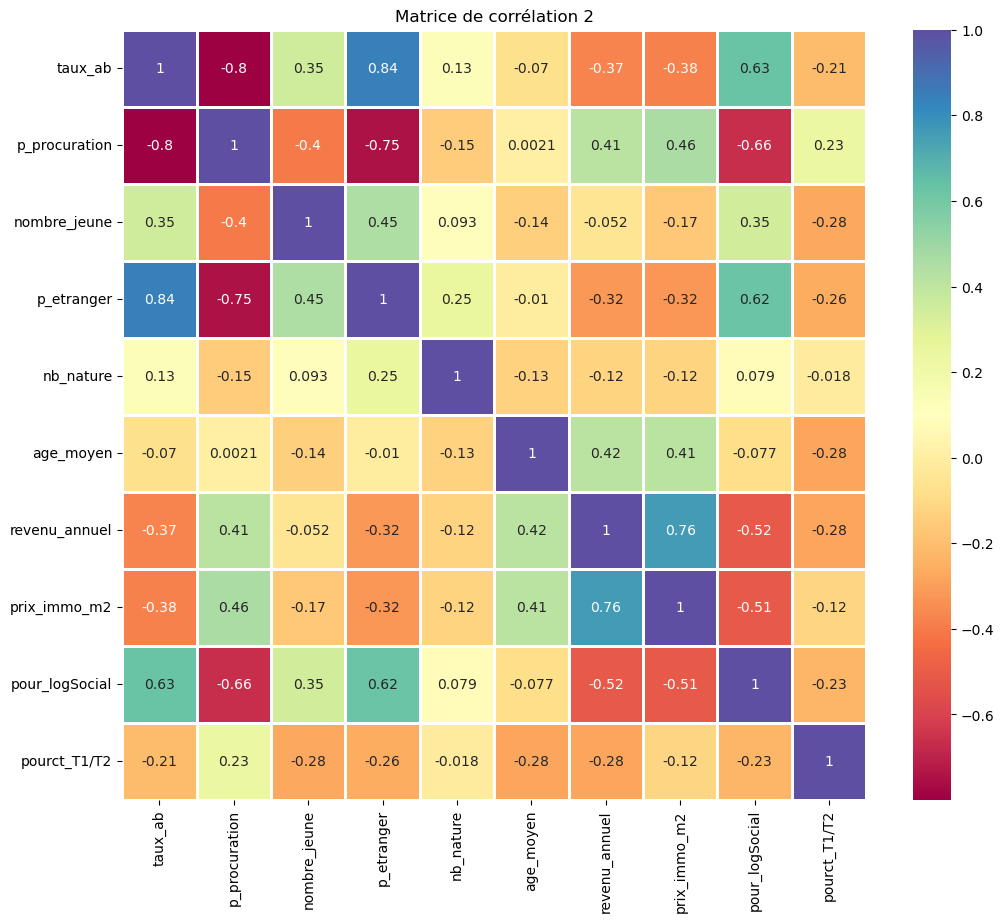

In [63]:
#Matrice de corrélation avec Seaborn

plt.figure(figsize=(12,10))

sns.heatmap(quant_corr,cmap="Spectral",annot=True,linewidth=0.9)
plt.title("Matrice de corrélation 2")

plt.show()

On remarque que l'abstentétisme est liés avec le taux d"étranger et le taux de logement sociaux 

### 3-2 Régression linéaire 


L'idéal est d'analyser ces corrélation avec la regressionn linéaire 



In [64]:
#Importation des données de regression linéaires

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

#### Le taux d'abstention avec le taux d'étranger 

In [65]:
#regression linéaire


Y = pd.DataFrame(quant['p_etranger'])
X = quant[['taux_ab']]
X = X.copy() # On modifiera X, on en crée donc une copie
X['intercept'] = 1.
result = sm.OLS(Y, X).fit() # OLS = Ordinary Least Square (Moindres Carrés Ordinaire)

#On cherche le coeffcient directeurs
a = result.params['taux_ab']

# L'ordonnée a l'origine
b = result.params['intercept']

result.params

taux_ab      0.737478
intercept   -0.010707
dtype: float64

On y voit que cette fonction est  Y = 0.74*X-0.01


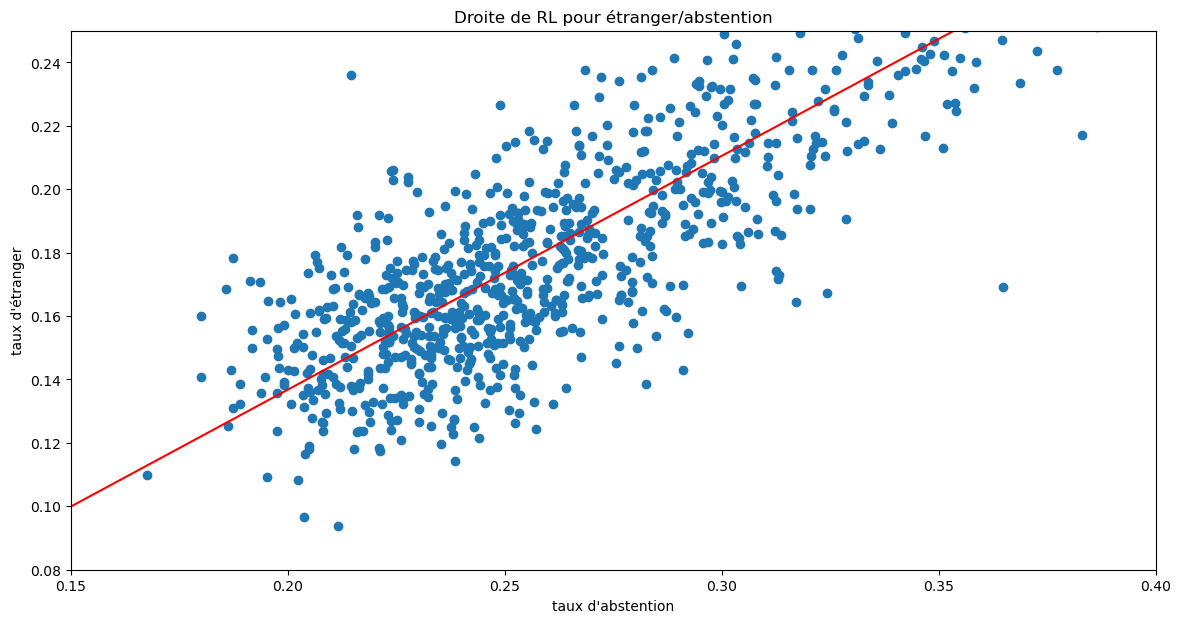

In [66]:
print(f'On y voit que cette fonction est  Y = {round(a,2)}*X{round(b,2)}')

#on affiche graphiquement la droite de regression

plt.figure(figsize=(14,7))

plt.scatter(quant['taux_ab'],quant['p_etranger'])
plt.plot(np.arange(len(quant['p_etranger'])),[a*x+b for x in np.arange(len(quant['p_etranger']))],c='r')
plt.xlabel("taux d'abstention")
plt.ylabel("taux d'étranger")
plt.xlim(0.15,0.4)
plt.ylim(0.08,0.25)
plt.title("Droite de RL pour étranger/abstention")
plt.savefig("RegLin_etr_abs.png")
plt.show()

### Taux d'abstention avec le taux de logement sociaux 

In [67]:
#regression linéaire


Y = pd.DataFrame(quant['pour_logSocial'])
X = quant[['taux_ab']]
X = X.copy() # On modifiera X, on en crée donc une copie
X['intercept'] = 1.
result = sm.OLS(Y, X).fit() # OLS = Ordinary Least Square (Moindres Carrés Ordinaire)

#On cherche le coeffcient directeurs
a = result.params['taux_ab']

# L'ordonnée a l'origine
b = result.params['intercept']

result.params

taux_ab      2.874613
intercept   -0.570163
dtype: float64

On y voit que cette fonction est  Y = 2.87*X-0.57


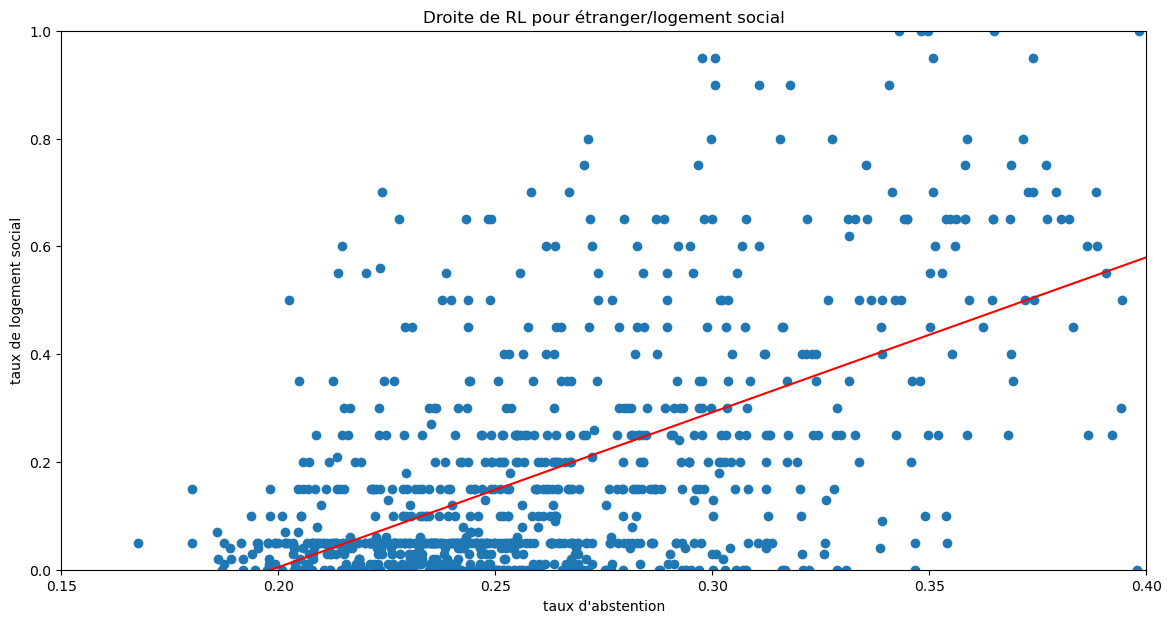

In [68]:
print(f'On y voit que cette fonction est  Y = {round(a,2)}*X{round(b,2)}')

#on affiche graphiquement la droite de regression

plt.figure(figsize=(14,7))

plt.scatter(quant['taux_ab'],quant['pour_logSocial'])
plt.plot(np.arange(len(quant['pour_logSocial'])),[a*x+b for x in np.arange(len(quant['pour_logSocial']))],c='r')
plt.xlabel("taux d'abstention")
plt.ylabel("taux de logement social")
plt.xlim(0.15,0.4)
plt.ylim(0,1)
plt.title("Droite de RL pour étranger/logement social")
plt.savefig("RegLin_LogSocial_abs.png")
plt.show()

### 3-3 Analyse des taux d'abtention en rapport avec les données élecorales 

In [69]:
leg24

,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,taux_ab,nb_abscent,taux_ab_leg
id_bv,,,,,,,,,,,,,,,,,
01_01,1,129,1080,781,781,7,1,773,3,279,324,70,96,1,0.276852,299,0.276852
01_02,1,137,1211,904,904,5,4,895,0,312,414,73,91,5,0.253509,307,0.253509
01_03,1,140,1211,874,874,3,5,866,8,315,346,65,130,2,0.278282,337,0.278282
01_04,1,133,1295,912,912,7,5,900,18,416,315,45,106,0,0.295753,383,0.295753
01_05,1,145,1077,823,823,3,2,818,1,320,356,56,82,3,0.235840,254,0.235840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20_72,6,196,1746,1229,1230,14,7,1209,12,904,174,40,79,0,0.295533,516,0.295533
20_73,6,194,1712,1306,1306,11,6,1289,12,923,250,29,75,0,0.237150,406,0.237150
20_74,6,233,1760,1348,1347,19,8,1320,15,978,229,23,75,0,0.234659,413,0.234659


In [70]:
leg = leg24.drop(["num_circo","nb_inscr","nb_emarg","nb_votant","nb_nul","nb_bl","taux_ab","nb_abscent"],axis=1)

leg

,nb_procu,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,taux_ab_leg
id_bv,,,,,,,,,
01_01,129,773,3,279,324,70,96,1,0.276852
01_02,137,895,0,312,414,73,91,5,0.253509
01_03,140,866,8,315,346,65,130,2,0.278282
01_04,133,900,18,416,315,45,106,0,0.295753
01_05,145,818,1,320,356,56,82,3,0.235840
...,...,...,...,...,...,...,...,...,...
20_72,196,1209,12,904,174,40,79,0,0.295533
20_73,194,1289,12,923,250,29,75,0,0.237150
20_74,233,1320,15,978,229,23,75,0,0.234659


In [71]:
eur24.columns

Index(['nb_procu', 'taux_procu', 'nb_inscr', 'nb_abscent', 'taux_abst',
       'nb_emarg', 'nb_votant', 'nb_bl', 'nb_nul', 'nb_exprim', 'NB_ExtGauche',
       'NB_Gauche', 'NB_Centre', 'NB_Droite', 'NB_ExtDroite', 'NB_Divers',
       'voix_Gauche', 'voix_Droite', 'taux_ab'],
      dtype='object')

In [72]:
eur24

,nb_procu,taux_procu,nb_inscr,nb_abscent,taux_abst,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,voix_Gauche,voix_Droite,taux_ab
id_bv,,,,,,,,,,,,,,,,,,,
01_01,37,"0,0337",1099,456,"0,4149",643,643,1,3,639,2,293,144,74,114,12,295,188,0.418562
01_02,59,"0,0479",1232,537,"0,4359",695,695,4,5,686,1,328,193,56,98,10,329,154,0.443182
01_03,56,"0,0457",1225,468,"0,382",756,757,3,6,748,3,366,177,58,125,19,369,183,0.389388
01_04,48,"0,0366",1310,569,"0,4344",741,741,0,9,732,4,386,146,52,123,21,390,175,0.441221
01_05,48,"0,044",1090,444,"0,4073",647,646,2,0,644,1,337,149,47,106,4,338,153,0.409174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20_72,66,"0,0374",1763,785,"0,4453",978,978,7,5,966,10,735,75,38,95,13,745,133,0.452070
20_73,0,0,1747,657,"0,3761",1090,1090,3,1,1086,11,848,102,31,88,6,859,119,0.378363
20_74,110,"0,062",1775,634,"0,3572",1141,1141,4,5,1132,3,913,94,33,73,16,916,106,0.362254


In [73]:
taux_abst_eur = pd.DataFrame(eur24["taux_ab"])

taux_abst_eur

,taux_ab
id_bv,
01_01,0.418562
01_02,0.443182
01_03,0.389388
01_04,0.441221
01_05,0.409174
...,...
20_72,0.452070
20_73,0.378363
20_74,0.362254


In [74]:
#Données de gauche

gauche = pd.read_csv("res_gauche.csv",sep=";",encoding="ISO-8859-1")

gauche = gauche.rename(columns = {"ï»¿id_bv":"id_bv"})

gauche = gauche.set_index("id_bv",drop="True")

gauche_quant = gauche.drop("partie_dominant",axis=1)

gauche_quant.head(5)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche
id_bv,,,,,,,,,,,
01_01,295,282,-13,0.4617,0.3648,136,66,4,84,3,2
01_02,329,312,-17,0.4796,0.3486,171,72,5,71,9,1
01_03,369,323,-46,0.4933,0.3730,178,86,11,86,5,3
01_04,390,434,44,0.5328,0.4822,175,66,15,125,5,4
01_05,338,321,-17,0.5248,0.3924,173,79,5,75,5,1


In [75]:
#Données de droite

droite = pd.read_csv("res_droite.csv",sep=";",encoding="ISO-8859-1")

droite = droite.rename(columns = {"ï»¿id_bv":"id_bv"})

droite = droite.set_index("id_bv",drop="True")

droite_quant = droite.drop("partie_dominant",axis=1)

droite_quant.head(5)


,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
id_bv,,,,,,,,,,
01_01,188,0.2942,166,0.2147,-22,72,60,42,2,12
01_02,154,0.2245,164,0.1832,10,54,54,37,2,7
01_03,183,0.2447,195,0.2252,12,58,71,37,0,17
01_04,175,0.2391,151,0.1678,-24,51,69,34,1,20
01_05,153,0.2376,138,0.1687,-15,44,53,41,3,12


In [76]:
res_politique = gauche_quant.merge(droite_quant,on="id_bv")

res_politique.head(5)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,...,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,295,282,-13,0.4617,0.3648,136,66,4,84,3,...,188,0.2942,166,0.2147,-22,72,60,42,2,12
01_02,329,312,-17,0.4796,0.3486,171,72,5,71,9,...,154,0.2245,164,0.1832,10,54,54,37,2,7
01_03,369,323,-46,0.4933,0.3730,178,86,11,86,5,...,183,0.2447,195,0.2252,12,58,71,37,0,17
01_04,390,434,44,0.5328,0.4822,175,66,15,125,5,...,175,0.2391,151,0.1678,-24,51,69,34,1,20
01_05,338,321,-17,0.5248,0.3924,173,79,5,75,5,...,153,0.2376,138,0.1687,-15,44,53,41,3,12


In [77]:
res_politique = taux_abstention.merge(res_politique,on='id_bv')

res_politique.head(5)

,taux_ab,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,...,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
id_bv,,,,,,,,,,,,,,,,,,,,,
01_01,0.276852,295,282,-13,0.4617,0.3648,136,66,4,84,...,188,0.2942,166,0.2147,-22,72,60,42,2,12
01_02,0.253509,329,312,-17,0.4796,0.3486,171,72,5,71,...,154,0.2245,164,0.1832,10,54,54,37,2,7
01_03,0.278282,369,323,-46,0.4933,0.3730,178,86,11,86,...,183,0.2447,195,0.2252,12,58,71,37,0,17
01_04,0.295753,390,434,44,0.5328,0.4822,175,66,15,125,...,175,0.2391,151,0.1678,-24,51,69,34,1,20
01_05,0.235840,338,321,-17,0.5248,0.3924,173,79,5,75,...,153,0.2376,138,0.1687,-15,44,53,41,3,12


In [78]:
politique_quant = res_politique.reset_index()

politique_quant = politique_quant.drop('id_bv',axis=1)

politique_quant

,taux_ab,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,...,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
0,0.276852,295,282,-13,0.4617,0.3648,136,66,4,84,...,188,0.2942,166,0.2147,-22,72,60,42,2,12
1,0.253509,329,312,-17,0.4796,0.3486,171,72,5,71,...,154,0.2245,164,0.1832,10,54,54,37,2,7
2,0.278282,369,323,-46,0.4933,0.3730,178,86,11,86,...,183,0.2447,195,0.2252,12,58,71,37,0,17
3,0.295753,390,434,44,0.5328,0.4822,175,66,15,125,...,175,0.2391,151,0.1678,-24,51,69,34,1,20
4,0.235840,338,321,-17,0.5248,0.3924,173,79,5,75,...,153,0.2376,138,0.1687,-15,44,53,41,3,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896,0.295533,745,916,171,0.7712,0.7577,196,133,21,378,...,133,0.1377,119,0.0984,-14,32,58,23,6,14
897,0.237150,859,935,76,0.7910,0.7254,307,195,18,323,...,119,0.1096,104,0.0807,-15,30,46,21,1,21
898,0.234659,916,993,77,0.8092,0.7523,317,197,28,364,...,106,0.0936,98,0.0742,-8,31,35,17,2,21
899,0.349785,686,898,212,0.7804,0.7636,142,117,21,386,...,125,0.1422,115,0.0978,-10,30,52,24,3,16


In [79]:
### Matrice de corrélation 

politique_corr = politique_quant.corr()

politique_corr

,taux_ab,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,...,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
taux_ab,1.000000,-0.181907,0.067645,0.683494,0.154209,0.294746,-0.594286,-0.416568,0.048824,0.424015,...,-0.174027,0.054869,-0.055980,0.093863,0.364654,-0.326197,0.277129,-0.142840,-0.015738,0.178115
total_G_EUR,-0.181907,1.000000,0.953458,0.353776,0.873055,0.801132,0.833208,0.919586,0.706295,0.745999,...,-0.693441,-0.885193,-0.661430,-0.823923,0.174523,-0.670187,-0.438472,-0.662502,0.088820,0.113911
total_G_LEG,0.067645,0.953458,1.000000,0.619336,0.936825,0.920069,0.656787,0.799818,0.731878,0.885098,...,-0.768243,-0.892887,-0.702814,-0.823848,0.280744,-0.784207,-0.380219,-0.732799,0.097408,0.178681
ecart_voix_G,0.683494,0.353776,0.619336,1.000000,0.632727,0.768027,-0.132198,0.086570,0.431196,0.803101,...,-0.577473,-0.464823,-0.457863,-0.410204,0.416434,-0.687542,-0.037722,-0.548086,0.070884,0.257661
p_G_EUR,0.154209,0.873055,0.936825,0.632727,1.000000,0.977066,0.571275,0.709609,0.691204,0.851676,...,-0.914697,-0.955495,-0.842696,-0.889135,0.317053,-0.909960,-0.501238,-0.861596,0.040500,0.091142
p_G_LEG,0.294746,0.801132,0.920069,0.768027,0.977066,1.000000,0.433811,0.600589,0.687376,0.893819,...,-0.890061,-0.895425,-0.804446,-0.827201,0.353874,-0.918238,-0.406468,-0.841260,0.057667,0.153079
nb_PS,-0.594286,0.833208,0.656787,-0.132198,0.571275,0.433811,1.000000,0.877988,0.482998,0.268785,...,-0.451138,-0.700551,-0.494879,-0.683922,-0.074771,-0.367329,-0.436830,-0.451514,0.078018,-0.002338
nb_EELV,-0.416568,0.919586,0.799818,0.086570,0.709609,0.600589,0.877988,1.000000,0.562158,0.498724,...,-0.555791,-0.776192,-0.566361,-0.739777,0.034223,-0.480497,-0.508393,-0.514935,0.040377,-0.016377
nb_PCF,0.048824,0.706295,0.731878,0.431196,0.691204,0.687376,0.482998,0.562158,1.000000,0.635014,...,-0.548227,-0.643781,-0.491148,-0.575155,0.230637,-0.596476,-0.166457,-0.538516,0.155093,0.188101
nb_LFI,0.424015,0.745999,0.885098,0.803101,0.851676,0.893819,0.268785,0.498724,0.635014,1.000000,...,-0.684712,-0.717665,-0.573099,-0.630266,0.405663,-0.753211,-0.217465,-0.640613,0.075028,0.233959


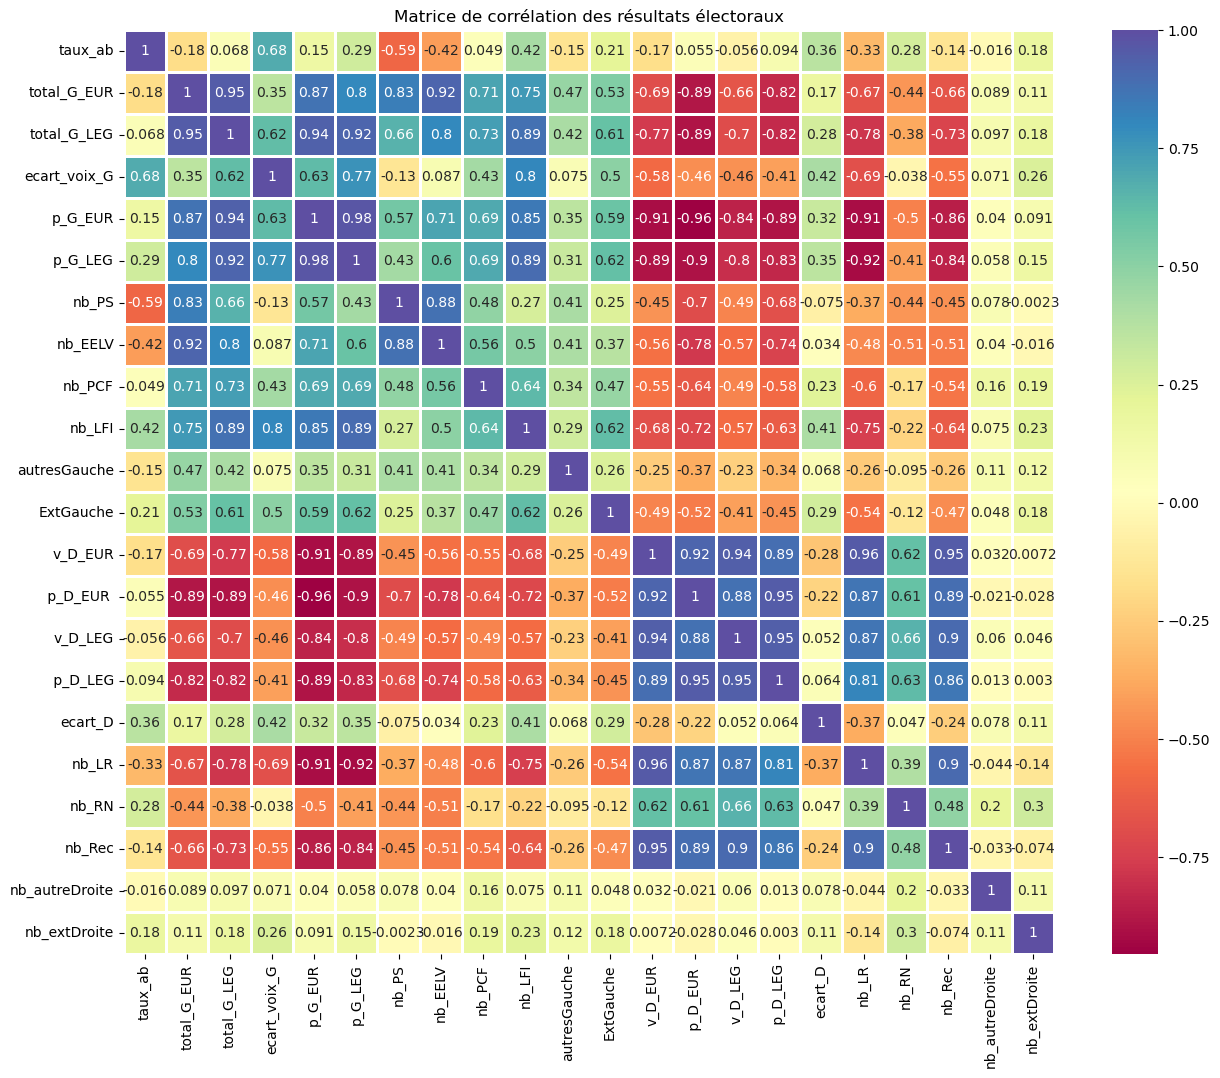

In [80]:
#Matrice de corrélation avec Seaborn

plt.figure(figsize=(15,12))

sns.heatmap(politique_corr,cmap="Spectral",annot=True,linewidth=0.9)
plt.title("Matrice de corrélation des résultats électoraux")

plt.show()

On remarque des corrélation entre l'abstention et certain parties politiques 

### Enregistrement des résultats

In [81]:
# Utilistion des résultats électoraux par politique 
res_politique.to_csv('correlation_politique.csv', index=True)

#Matrice de corrélation des politiques 
politique_corr.to_csv('matrice corrélation politiques.csv',index=False)


#Utilisation des donnés quantitatives (hors résultats electorales)

quant.to_csv("Données quantitatives.csv",index=True)


quant_corr.to_csv("Matrices des corrélation.csv",index=False)